In [ ]:
!pip install -U bitsandbytes transformers accelerate lime captum

In [1]:
from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os
import sys

path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        print("utils.py not found in any parent folder. Please upload.")
        upload_utils = files.upload()
        break
    path = new_path

import utils
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch
import random

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'scitail',
                'quantization': 'full',
                'training_mode': 'few shot',
                'model_id': 'meta-llama/Llama-3.2-3B-Instruct'}

# Create checkpoint path
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Zero-Shot/checkpoint_scitail_Llama_3.2_3B_Instruct_full_zero_shot.pt


In [4]:
utils.hf_login("HF_TOKEN")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])
model = AutoModelForCausalLM.from_pretrained(
    global_params['model_id'],
    device_map="auto",
    attn_implementation="eager"
    )

# Add padding token to the tokenizer and change padding side
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Change the model to evaluation mode
model.eval()

In [ ]:
# Lock 10 examples to be used for few shot
scitail_test = pd.read_csv('scitail_test.csv')

rng = random.Random(42)
all_indices = list(range(len(scitail_test)))
demo_indices = rng.sample(all_indices, 10) # Lock 10 random examples to be used as demos for few shot

demo_examples = scitail_test.loc[demo_indices]
scitail_test_few_shot = scitail_test.drop(index=demo_indices).reset_index(drop=True)

Saving scitail_test.csv to scitail_test.csv


In [ ]:
demo_examples

In [ ]:
# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nPremise: {demo_examples.iloc[i]['premise']}\nHypothesis: {demo_examples.iloc[i]['hypothesis']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

In [ ]:
scitail_test_few_shot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   premise                     2126 non-null   object
 1   hypothesis                  2126 non-null   object
 2   label                       2126 non-null   object
 3   hypothesis_graph_structure  2126 non-null   object
dtypes: object(4)
memory usage: 66.6+ KB


In [ ]:
scitail_test_few_shot.head(10)

,premise,hypothesis,label,hypothesis_graph_structure
0,Based on the list provided of the uses of subs...,"If a substance has a ph value greater than 7,t...",neutral,a substance<>has<>a ph value greater than 7
1,If one or two base pairs are change...,Invertebrates (and higher animals) can also be...,neutral,Invertebrates (and higher animals<>can be plac...
2,"At high temperatures, the solid dye converts i...",Gases and liquids become solids at low tempera...,neutral,Gases and liquids<>become<>solids
3,Chapter 11 Gas and Kinetic Theory .,The behavior of ideal gases is explained by ki...,neutral,The behavior of ideal gases<>is explained<>by ...
4,Both the continental crust and the oceanic cru...,Gabbro is a dark dense rock that can be found ...,neutral,Gabbro<>is<>a dark dense rock that can be foun...
5,The phylum for common marigolds is angiosperms.,Angiosperms are the most successful phylum of ...,neutral,Angiosperms<>are<>the most successful phylum o...
6,Lyme Disease is caused by a bacterium that's ...,Lyme disease is caused by bacteria.,entails,Lyme disease<>is caused<>by bacteria
7,Corolla Collective term for all the petals of ...,All of the petals together are called a corolla.,entails,All of the petals<>together are called<>a corolla
8,A polyploid is simply an organism that contain...,A(n) polyploid is an individual with more than...,entails,A(n) polyploid<>is<>an individual with more th...
9,Because type 1 diabetes is a relatively rare d...,Diabetes is unpreventable in the type one form...,neutral,Diabetes<>is<>unpreventable$$$it<>is<>of the s...


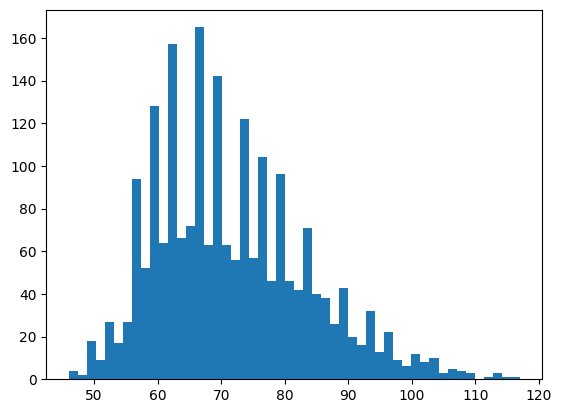

Max prompt length: 117
Max label length: 2


In [ ]:
# Find the max_length for tokenization to avoid wasting computing.
utils.find_max_length(scitail_test_few_shot, tokenizer=tokenizer, dataset_type=global_params['dataset_type'], examples=prompt_examples)

In [ ]:
prompt_lengths, _ = utils.get_lengths(scitail_test_few_shot, tokenizer, global_params['dataset_type'], examples=prompt_examples)
df = pd.DataFrame(prompt_lengths, columns=["length"])
tokens = 619 # Max length to check
n = (df["length"] > tokens).sum() # Number of prompts with # > tokens
percent = round(n/len(df)*100, 3)
print(f"Number of examples that have over {tokens} tokens and will be truncated: {n} out of {len(df)} examples or {percent}%")

In [ ]:
# Define dataset and create a dataloader.
dataset_test = utils.MyDataset_few_shot(dataframe=scitail_test_few_shot,
                               examples=prompt_examples,
                               tokenizer=tokenizer,
                               dataset_type=global_params['dataset_type'],
                               prompt_max_length=117,
                               label_max_length=3)

batch_size = 5 # Change batch size according to GPU
dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [ ]:
# Show an example prompt
print(dataset_test[0]['prompt'])

In [22]:
# Test
predictions, gold_labels, batch_probs = utils.test_run(model=model,
                                          dataloader=dataloader,
                                          tokenizer=tokenizer,
                                          dataset_type=global_params['dataset_type'])

for i, pair in enumerate(zip(predictions, gold_labels)):
    print(pair, batch_probs[i])

('entails', 'neutral') tensor([0.6566, 0.3434], device='cuda:0')
('neutral', 'neutral') tensor([0.1849, 0.8151], device='cuda:0')
('neutral', 'neutral') tensor([0.2234, 0.7766], device='cuda:0')
('neutral', 'neutral') tensor([0.3242, 0.6758], device='cuda:0')
('neutral', 'neutral') tensor([0.2648, 0.7352], device='cuda:0')


In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        # Try to catch NaN values
        if torch.isnan(batch_probs).any():
            print("Warning: NaNs detected in batch_probs")

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Few-Shot/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_shot_1_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Few-Shot/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_shot_1_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Few-Shot/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_shot_2_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Few-Shot/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_s

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

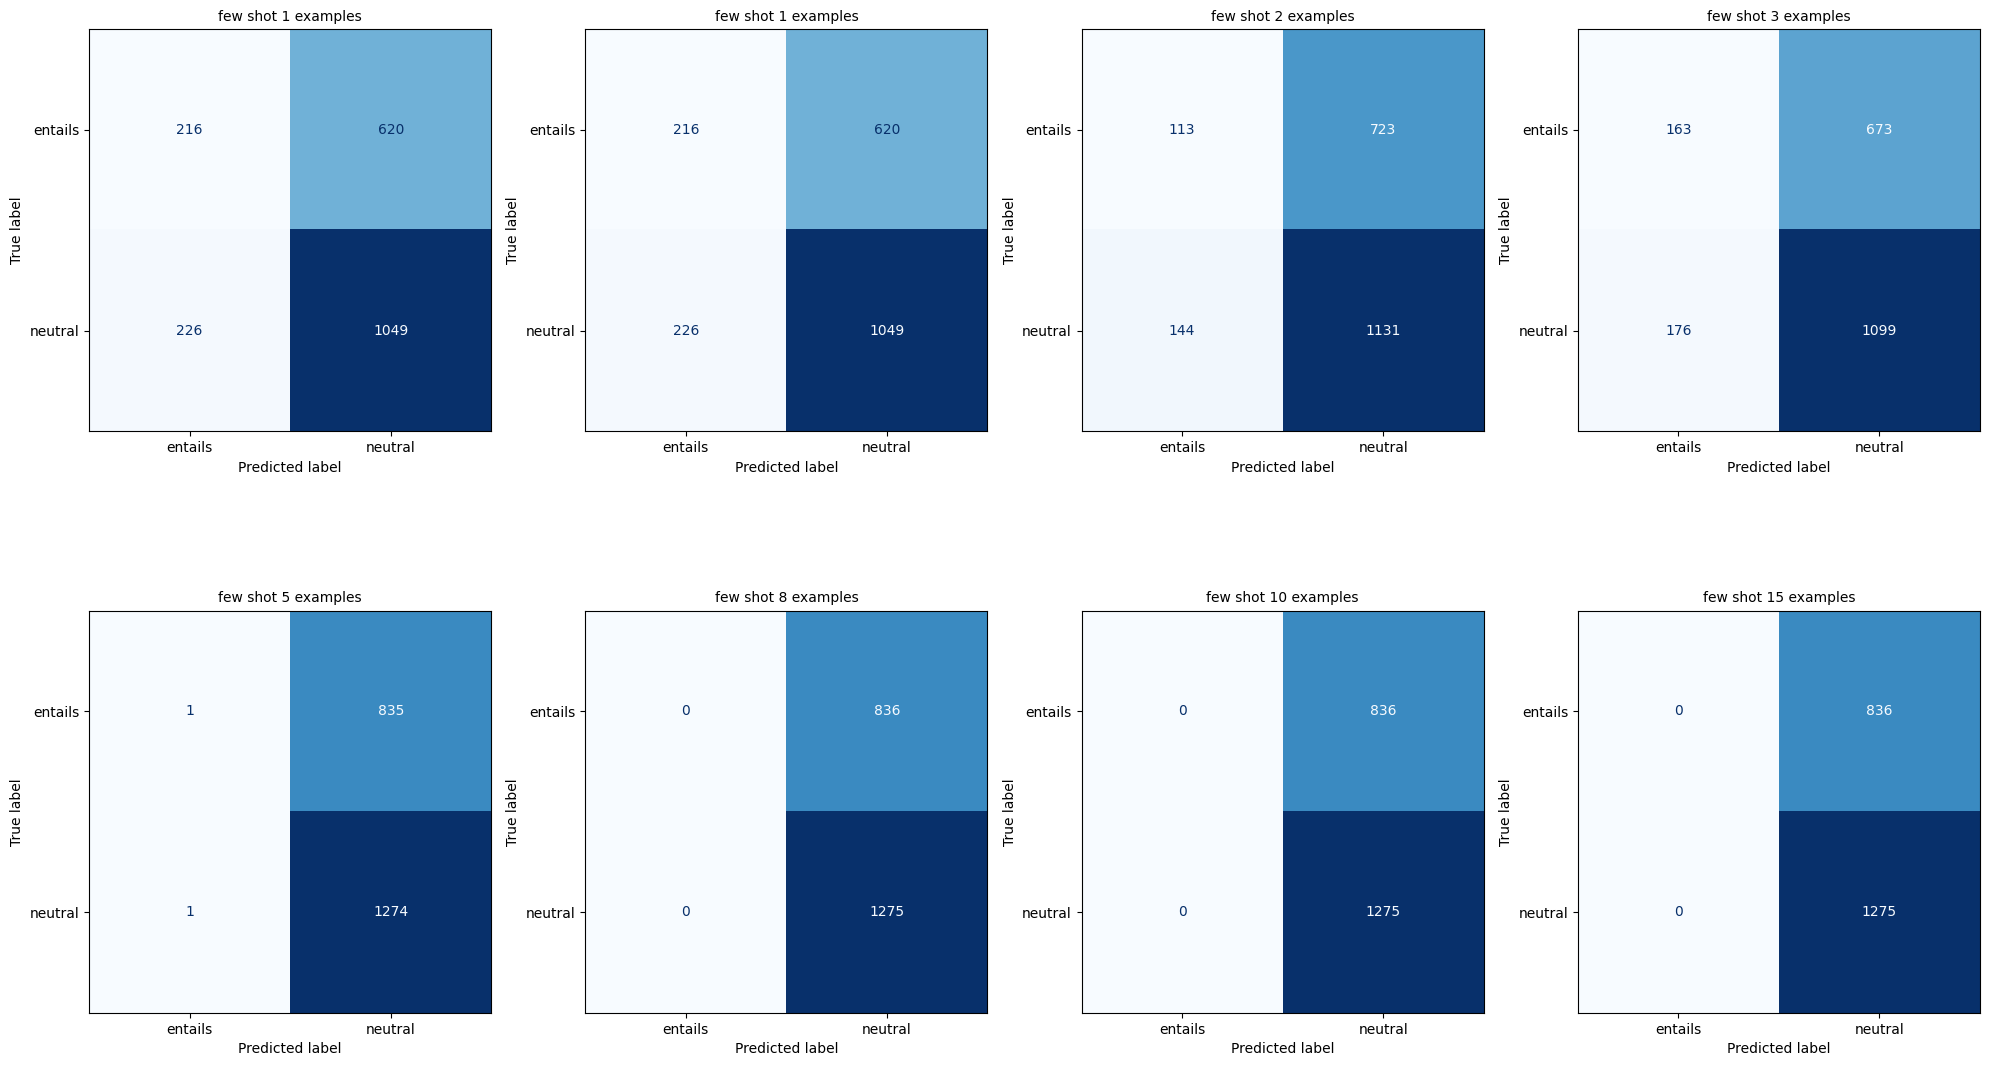

In [2]:
import matplotlib.pyplot as plt

examples_no = [1, 2, 3, 5, 8, 10, 15]
fig, axes = plt.subplots(2, 4, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

idx = 0
for k in examples_no:
    global_params = {
            'dataset_type': 'scitail',
            'quantization': 'full',
            'training_mode': f'few shot {k} examples',
            'model_id': 'meta-llama/Llama-3.2-3B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

    idx += 1

    if k == 1:
        global_params = {
            'dataset_type': 'scitail',
            'quantization': 'full',
            'training_mode': f'few shot {k} examples',
            'model_id': 'meta-llama/Llama-3.2-3B-Instruct'
        }
        checkpoint_path = utils.create_checkpoint_path(params=global_params)
        predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

        acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                                predicted_labels=predicted_labels,
                                                gold_labels=gold_labels,
                                                params=global_params,
                                                ax=axes[idx]
                                                )   
        accs.append(round(acc, 4))
        precisions.append(round(precision, 4))
        recalls.append(round(recall, 4))
        f1s.append(round(f1, 4))
        mccs.append(round(mcc, 4))
        kappas.append(round(kappa, 4))

        idx += 1


plt.tight_layout()
plt.show()

In [3]:
idx = [f"{k} examples" for k in examples_no]
idx.append("1 examples opposite")

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
    "F1": f1s,
    "MCC": mccs,
    "Kappa": kappas},
    index= idx
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
1 examples,0.5992,0.5586,0.5406,0.5253,0.0975,0.0883
2 examples,0.5992,0.5586,0.5406,0.5253,0.0975,0.0883
3 examples,0.5893,0.5249,0.5111,0.4648,0.0332,0.0252
5 examples,0.5978,0.5505,0.5285,0.4994,0.0758,0.0634
8 examples,0.6040,0.5520,0.5002,0.3777,0.0065,0.0005
10 examples,0.6040,0.3020,0.5000,0.3766,0.0000,0.0000
15 examples,0.6040,0.3020,0.5000,0.3766,0.0000,0.0000
1 examples opposite,0.6040,0.3020,0.5000,0.3766,0.0000,0.0000


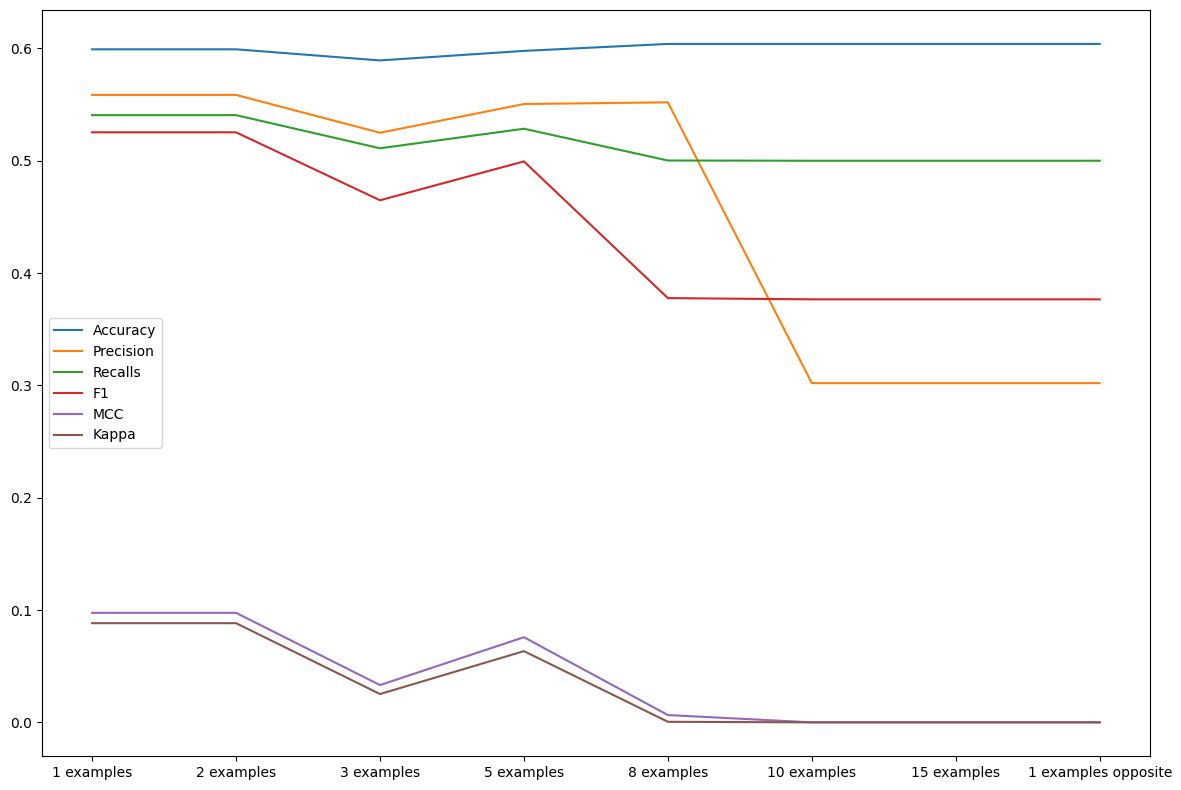

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))
metrics_df.plot(kind='line', ax=ax)
plt.tight_layout()
plt.show()